In [1]:
import pandas as pd 
import numpy as np
import os 
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 

import numpy as np
import matplotlib.dates as mdates

# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')



def format_date_ax(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

In [2]:
# mixed_depth = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/TempDens_parametersbydepth.csv")
# mixed_depth = mixed_depth.loc[mixed_depth.SITE == "WEB"]
# print(mixed_depth.columns)
# mixed_depth['time'] = pd.to_datetime(mixed_depth['TIMESTAMP'])
# mixed_depth.loc[mixed_depth["Depth_MixedLayer_Max_60min_movavg"] > 5] = np.nan


temp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/turbulence-model/data/forcing_data/data/Temperature_processed.csv")
temp = temp.loc[temp.SITE == "WEB"]
temp = temp.loc[temp.STAT == "Average"]
temp.reset_index(inplace=True)
temp['time'] = pd.to_datetime(temp['TIMESTAMP'])
temp.drop(columns=['STAT', 'SITE', "SENSOR", "Interval", "TIMESTAMP"], inplace=True)
temp['day'] = temp['time'].dt.day
# print(temp)


import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)


In [3]:
wind = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/wind/Wind_processed.csv")
wind = wind.loc[wind.STAT == "Average"]
wind = wind.loc[wind.SITE == "WEB"]
wind['time'] = pd.to_datetime(wind['TIMESTAMP'], format="%Y-%m-%dT%H:%M:%SZ")


In [4]:
# Chlorophyll-a data
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-16/chla_for_adjoint.csv")
chla['time'] = pd.to_datetime(chla['time'])
obs = chla.pg_chla_perML 

# Rolling average to smooth the data
obs_roll = obs.rolling(window=10, center=True).mean()
chla['obs_roll'] = obs_roll

# mixed_depth = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/TempDens_parametersbydepth.csv")
# mixed_depth = mixed_depth.loc[mixed_depth.SITE == "WEB"]
# mixed_depth['time'] = pd.to_datetime(mixed_depth['TIMESTAMP'])
# mixed_depth.loc[mixed_depth["Depth_MixedLayer_Max_60min_movavg"] > 5] = np.nan

In [ ]:
# zscales = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/Diffusivity_zscales.csv")
# zscales['time'] = pd.to_datetime(zscales.timestamp_round15) 
# zscales['photic'] = zscales["z_mixed_60minmovavg_sd"]
# zscales = zscales.loc[zscales.site == "WEB"]
# zscales.drop(columns=['site', 'date', 'microctd_timestamp', 'timestamp_round15'], inplace=True)
# print(zscales.columns)


Index(['z_mixed_60minmovavg_masked', 'z_mixed_60minmovavg_max',
       'z_mixed_60minmovavg_sd', 'z_eu_site_avg', 'z_eu_site_sd',
       'z_eu_overall_avg', 'z_eu_overall_sd', 'z_eu_sitevisit_avg', 'time',
       'photic'],
      dtype='object')


In [5]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(6, 27): 
    temp0 = temp.loc[temp.day == d]

 
    time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig = plt.figure(figsize=(10,3.5))
    ax = fig.gca() 

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)

    b = ax.pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    # axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    ax.plot(X[mask], -averaged_md[mask], '-', color="k",linewidth=1, alpha=0.58, label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")

    c = ax.scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 

    plt.colorbar(b, ax=ax, label=r'Temperature ($^{\circ}$C)', orientation='vertical', shrink = 0.63) 
    plt.colorbar(c, ax=ax, label=r"Temperature gradient ($^{\circ}$C m$^{-1}$)" , orientation='horizontal', shrink = 0.43 , pad=0.15) 
    ax.set_xlim(time[0], time[-1])
    format_date_ax(ax)
    ax.set_ylabel("Depth (m)")
    ax.legend(loc='lower left')
    plt.tight_layout()
    fig.savefig("plots/dwl_august_%02d.png" % (d), dpi=300)
    plt.close()


In [8]:
# with wind
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(6, 27): 
    temp0 = temp.loc[temp.day == d]

 
    time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,4), height_ratios=(0.5, 1.5), sharex=True)

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)

    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    axs[0].plot(wind.time, wind.WindSpeed**3, '-k')
    axs[0].set_xlim(time[0], time[-1])
    axs[0].set_ylim(0, 170)
    axs[0].grid(alpha=0.3)
    axs[0].set_ylabel("Wind$^3$")
    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    # axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    axs[1].plot(X[mask], -averaged_md[mask], '-', color="k",linewidth=1, alpha=0.58, label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")

    c = axs[1].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 

    plt.colorbar(b, ax=ax, label=r'Temperature ($^{\circ}$C)', orientation='vertical', shrink = 0.63) 
    plt.colorbar(c, ax=ax, label=r"Temperature gradient ($^{\circ}$C m$^{-1}$)" , orientation='horizontal', shrink = 0.43 , pad=0.15) 
    ax.set_xlim(time[0], time[-1])
    format_date_ax(ax)
    axs[1].set_ylabel("Depth (m)")
    axs[1].legend(loc='lower left')
    plt.tight_layout()
    fig.savefig("plots/dwl_wind_august_%02d.png" % (d), dpi=300)
    plt.close()


In [6]:
days = range(6, 28)

days_fn = ["august_%02d" % day for day in days]
print(days_fn)

guess = {} 

# get list of files in finished/
read_in = os.listdir('finished/')
print(read_in)

import re

for file in read_in:
    if file.startswith('forward_1_') or file.startswith('adjoint'):
        pass
    else:
        # print(file)
        match = re.search(r'(\d+)(?=\.nc$)', file)
        day = match.group(1)
        guess[day] = xr.open_dataset('finished/%s' % (file), decode_timedelta=False)
        print("Opened day ", day)
        z = guess[day].z.values

    # Get last two digits 

# for i in read_in: #range(1, NITER):
#     guess[i] = xr.open_dataset('finished/forward__%s.nc' % (days_fn), decode_timedelta=False)

['august_06', 'august_07', 'august_08', 'august_09', 'august_10', 'august_11', 'august_12', 'august_13', 'august_14', 'august_15', 'august_16', 'august_17', 'august_18', 'august_19', 'august_20', 'august_21', 'august_22', 'august_23', 'august_24', 'august_25', 'august_26', 'august_27']
['adjoint_56_august_09.nc', 'adjoint_1_august_11.nc', 'forward_11_august_21.nc', 'adjoint_9_august_26.nc', 'adjoint_1_august_22.nc', 'forward_1_august_24.nc', 'adjoint_79_august_13.nc', 'adjoint_6_august_15.nc', 'forward_14_august_15.nc', 'forward_78_august_12.nc', 'adjoint_18_august_14.nc', 'adjoint_1_august_20.nc', 'forward_1_august_13.nc', 'forward_1_august_22.nc', 'forward_1_august_11.nc', 'forward_72_august_10.nc', 'adjoint_1_august_15.nc', 'adjoint_1_august_21.nc', 'forward_76_august_19.nc', 'forward_1_august_20.nc', 'adjoint_84_august_24.nc', 'adjoint_76_august_22.nc', 'adjoint_72_august_10.nc', 'adjoint_13_august_07.nc', 'forward_1_august_18.nc', 'adjoint_1_august_27.nc', 'forward_1_august_25.nc'

AssertionError: 

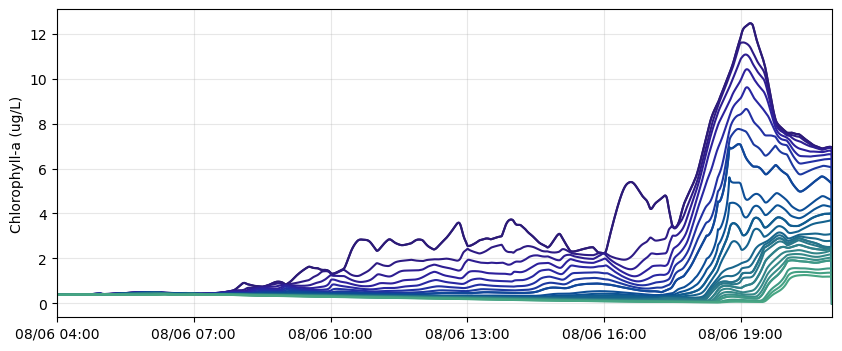

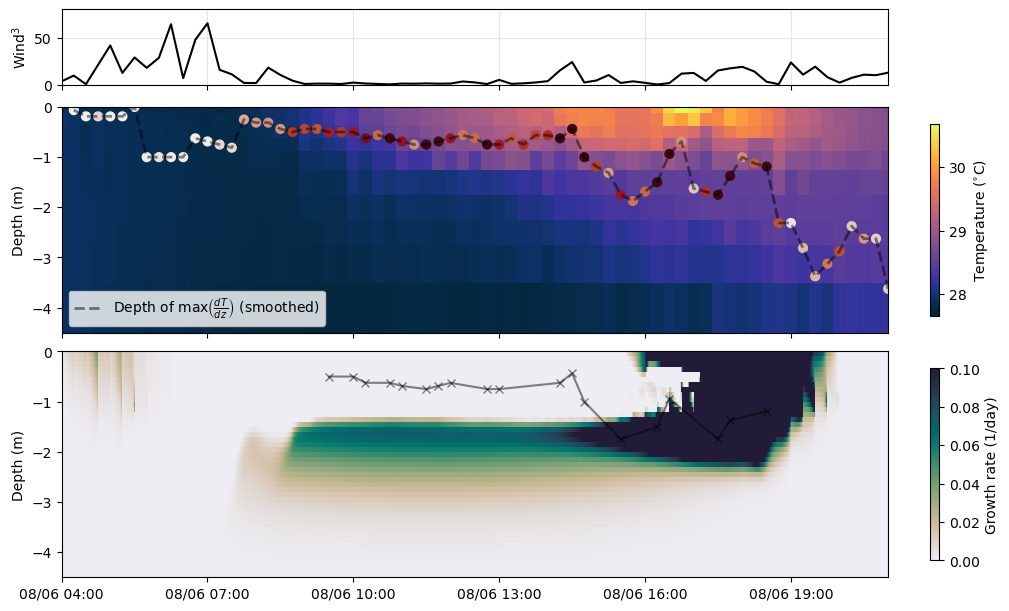

In [7]:
# with wind
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom


for d in [6]: 
    temp0 = temp.loc[temp.day == d]

 

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig = plt.figure(figsize=(10,4))
    ax = plt.gca() 
    for dz in np.arange(0, 3, 0.1):
        total_chla =  ds.algae1.sel(z=dz, method='nearest')*cell2chla_mc #
        # total_chla =  ds.algae2.sel(z=dz, method='nearest')*cell2chla_diatom
        ax.plot(time, total_chla*1e-3, color=cmo.cm.haline(dz/5))
    ax.set_ylabel("Chlorophyll-a (ug/L)")
    format_date_ax(ax)
    ax.grid(alpha=0.3)
    # ax.set_ylim(5,25)
    ax.set_xlim(time[0], time[-1])
    # ax.set_xlim(time[400], time[-3])

    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,6), height_ratios=(0.5, 1.5, 1.5), sharex=True, constrained_layout=True)

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)

    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    axs[0].plot(wind.time, wind.WindSpeed**3, '-k')
    axs[0].set_xlim(time[0], time[-1])
    axs[0].set_ylim(0, 80)
    axs[0].grid(alpha=0.3)
    axs[0].set_ylabel("Wind$^3$")
    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    # axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    axs[1].plot(X[mask], -averaged_md[mask], '--', color="k",linewidth=2, alpha=0.48, label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")

    c = axs[1].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 
    developed_layer = mask & (maxs>1)
    axs[2].plot(X[developed_layer], -averaged_md[developed_layer], '-x', color="k", alpha=0.48)


    format_date_ax(axs[2])
    axs[1].set_ylabel("Depth (m)")
    axs[2].set_ylabel("Depth (m)")
    axs[1].legend(loc='lower left')

    axs[0].set_xlim(time[0], time[-1])
    plt.colorbar(b, ax=axs[1], label=r'Temperature ($^{\circ}$C)', orientation='vertical', shrink = 0.85)
    # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 
    h = axs[2].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    plt.colorbar(h, ax=axs[2], orientation='vertical', label='Growth rate (1/day)', shrink=0.85)
    
    axs[1].set_ylim(-4.5, 0)
    axs[2].set_ylim(-4.5, 0)

    assert(False)
    fig.savefig("plots/growth+wind+temp_august_%02d.png" % (d), dpi=300)

    # assert(False)
    plt.close()


/global/homes/s/siennaw/.conda/envs/jupenv2/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/siennaw/.conda/envs/jupenv2/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


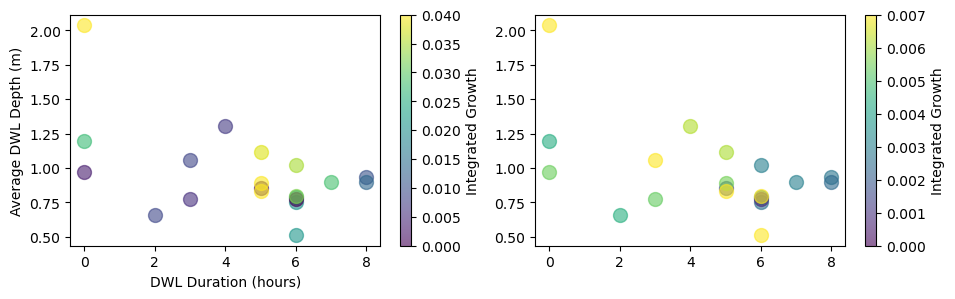

In [81]:
# with wind
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,3))
axs = axs.flatten()
for d in range(6, 27):
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    integrated_growth_mc = (ds.gamma1 * ds.algae1).sum(dim='z').sum(dim='t').clip(0,)
    integrated_growth_diatom = (ds.gamma2 * ds.algae2).sum(dim='z').sum(dim='t').clip(0,)

    time = Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)

    # b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')
    mask = (X > time[0]) # Crop to daytime hours

    mask = mask & (X < time[-1])
    developed_layer = mask & (maxs>1)
    try:
        duration =  np.timedelta64( X[developed_layer][-2] - X[developed_layer][2] ,'h').astype('timedelta64[h]').astype(float)
    except:
        duration = 0 
    average_depth = np.mean(averaged_md[developed_layer])
    h1 =  axs[0].scatter(duration, average_depth, c=integrated_growth_mc, vmin=0, vmax=0.04, s=100, alpha=0.6)
    h2 = axs[1].scatter(duration, average_depth, c=integrated_growth_diatom, vmin=0, vmax=0.007, s=100, alpha=0.6) #, color=cmo.cm.deep(d/27))

axs[0].set_xlabel("DWL Duration (hours)")
axs[0].set_ylabel("Average DWL Depth (m)")
plt.colorbar(h1, ax=axs[0], label='Integrated Growth', orientation='vertical')
plt.colorbar(h2, ax=axs[1], label='Integrated Growth', orientation='vertical')

In [8]:
# fig = plt.figure(figsize=(10,4))

# mixed_depth['day'] = mixed_depth['time'].dt.day
# mixed_depth['hour'] = mixed_depth['time'].dt.hour + mixed_depth['time'].dt.minute/60

# for d in range(6, 16): 
#     mixed0 = mixed_depth.loc[mixed_depth.day == d]
#     plt.plot(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9

# plt.legend(loc ='upper left', ncol=2)
# ax = plt.gca()
# ax.grid(alpha=0.5)
# ax.set_xlim(10, 20)
# ax.set_title("Depth of diurnal warm layer")
# ax.set_xlabel("Hour of day")
# ax.set_ylabel("Depth (m)")